# Ablation Study: Weather Feature Contribution on Tea Price Forecasting

### Assumptions
*   **Data Readiness:** The dataset is fully engineered, cleaned, and already contains target (price), segment, time-ordering columns (e.g., sale_no or date), as well as structural and weather variables.
*   **Leakage Prevention:** To accurately respect temporal causality without future information leakage, `TimeSeriesSplit` (with 5 folds) is strictly imposed after enforcing chronological sorting.
*   **Detection Strategy:** Feature groups (structural, current weather, lagged weather) can be automatically inferred via keyword matching in the column names, avoiding manual hardcoded lists.
*   **Baseline Model:** A `RandomForestRegressor` acts as the uniform test model across tests, though the configuration allows switching to XGBoost easily.

In [ ]:
# --- IMPORTS ---
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore benign warnings for cleaner output
warnings.filterwarnings('ignore')

In [ ]:
# --- CONFIGURATION VARIABLES ---
# Data locations
DATA_PATH = "../data/processed/tea_engineered_dataset.csv"  # UPDATE THIS PATH
TARGET_COL = "price"                                        # UPDATE THIS
SEGMENT_COL = "segment"                                     # UPDATE THIS
TIME_COL = "sale_no"                                        # UPDATE THIS (or use 'date' if applicable)

# Model Selection
# Sticking to a consistent baseline for fairness in ablation
MODEL_CHOICE = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Feature Keyword Detection
# Use lowercase parts of strings that identify weather variables and lag variables
WEATHER_KEYWORDS = ['rain', 'temp', 'humidity', 'sun', 'wind'] 
LAG_KEYWORDS = ['lag', '_l1', '_l2', '-1', '-2']               

# Columns that should never be used as predictive features
COLUMNS_TO_EXCLUDE = [TARGET_COL, SEGMENT_COL, TIME_COL, "date", "id", "elevation"]

In [ ]:
# --- FEATURE GROUPING LOGIC ---
def identify_feature_groups(all_columns):
    """
    Categorizes features into structural, current weather, and lagged weather 
    based on the configured keywords. 
    """
    # 1. Base feature pool 
    features = [col for col in all_columns if col not in COLUMNS_TO_EXCLUDE]
    
    # 2. Separate into structural and generic weather
    weather_feats = []
    structural_feats = []
    
    for col in features:
        is_weather = any(wk.lower() in col.lower() for wk in WEATHER_KEYWORDS)
        if is_weather:
            weather_feats.append(col)
        else:
            structural_feats.append(col)
            
    # 3. Separate generic weather into current vs lagged
    current_weather_feats = []
    lagged_weather_feats = []
    
    for col in weather_feats:
        is_lag = any(lk.lower() in col.lower() for lk in LAG_KEYWORDS)
        if is_lag:
            lagged_weather_feats.append(col)
        else:
            current_weather_feats.append(col)
            
    print("--- Feature Detection Summary ---")
    print(f"Total Usable Features: {len(features)}")
    print(f"  -> Structural Features: {len(structural_feats)}")
    print(f"  -> Current Weather Features: {len(current_weather_feats)}")
    print(f"  -> Lagged Weather Features: {len(lagged_weather_feats)}\n")
    
    if len(weather_feats) == 0:
        print("WARNING: No weather features detected! Please adjust your WEATHER_KEYWORDS.")
        
    # Return dictionary matching exactly to the 5 requested settings
    return {
        'full': features,
        'structural_only': structural_feats,
        'weather_only': weather_feats,
        'structural_plus_current_weather': structural_feats + current_weather_feats,
        'structural_plus_lagged_weather': structural_feats + lagged_weather_feats
    }

In [ ]:
# --- DATASET LOADING & PREPARATION ---
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset successfully loaded. Shape: {df.shape}")
except FileNotFoundError:
    print(f"ERROR: Dataset not found at {DATA_PATH}.")
    # Dummy data creation for testing if execution continues
    np.random.seed(42)
    dummy_data = {
        'sale_no': np.arange(200),
        'segment': ['A']*100 + ['B']*100,
        'price': np.random.uniform(500, 1500, 200),
        'rain_current': np.random.uniform(0, 50, 200),
        'temp_lag_1': np.random.uniform(20, 35, 200),
        'demand_volume': np.random.uniform(1000, 5000, 200)
    }
    df = pd.DataFrame(dummy_data)
    print("Generated dummy dataframe for dry-run code validation.")

# Strictly preserve temporal order to prevent Target Leakage 
df = df.sort_values(by=TIME_COL).reset_index(drop=True)

# Generate and lock in our feature combinations
feature_groups = identify_feature_groups(df.columns)

ERROR: Dataset not found at ../data/processed/tea_engineered_dataset.csv.
Generated dummy dataframe for dry-run code validation.
--- Feature Detection Summary ---
Total Usable Features: 3
  -> Structural Features: 1
  -> Current Weather Features: 1
  -> Lagged Weather Features: 1



In [ ]:
# --- EVALUATION LOOP SETUP ---
def evaluate_condition(model, X, y, cv):
    """
    Evaluates a specific X/y feature set utilizing TimeSeriesSplit.
    Returns metrics computed for each fold.
    """
    metrics = []
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test   = X.iloc[test_idx], y.iloc[test_idx]
        
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        preds = model.predict(X_test)
        
        # Evaluate
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        
        # Optional supporting metrics
        mae = mean_absolute_error(y_test, preds)
        mape = mean_absolute_percentage_error(y_test, preds)
        
        metrics.append({
            'fold': fold + 1,
            'rmse': rmse,
            'r2': r2,
            'mae': mae,
            'mape': mape,
            'n_train': len(X_train),
            'n_test': len(X_test)
        })
        
    return pd.DataFrame(metrics)

In [ ]:
# --- MAIN ABLATION EXECUTION END-TO-END ---
segments = df[SEGMENT_COL].unique()

# Initialize 5-fold Chronological CV
tscv = TimeSeriesSplit(n_splits=5)

all_fold_results = []
print("Starting Segment-by-Segment Ablation...\n" + "-"*40)

for segment in segments:
    print(f"Processing Segment: {segment}")
    
    # Filter and strictly re-sort chronologically per segment
    segment_df = df[df[SEGMENT_COL] == segment].sort_values(by=TIME_COL).reset_index(drop=True)
    
    # Safety Check: Guarantee sufficient historical records for a TimeSeriesSplit
    if len(segment_df) < 50:
        print(f"  -> WARNING: Skipping segment '{segment}' due to insufficient rows ({len(segment_df)}).")
        continue
    
    y = segment_df[TARGET_COL]
    
    # Run through all 5 feature settings
    for condition_name, feature_list in feature_groups.items():
        if len(feature_list) == 0:
            print(f"  -> WARNING: Condition '{condition_name}' generated 0 features. Skipping this condition.")
            continue
            
        X = segment_df[feature_list]
        
        # Run CV function
        fold_metrics_df = evaluate_condition(MODEL_CHOICE, X, y, tscv)
        
        # Label output metadata
        fold_metrics_df['segment'] = segment
        fold_metrics_df['condition'] = condition_name
        
        all_fold_results.append(fold_metrics_df)

# Consolidate results into a unified Dataframe
final_results_df = pd.concat(all_fold_results, ignore_index=True)
print("\nAblation Pipeline Completed Successfully!")

Starting Segment-by-Segment Ablation...
----------------------------------------
Processing Segment: A
Processing Segment: B

Ablation Pipeline Completed Successfully!


In [ ]:
# --- AGGREGATION & SUMMARY CREATION ---
print("Compiling Results Summary...")

# Calculate Mean and Std over the CV folds
summary_df = final_results_df.groupby(['segment', 'condition']).agg(
    rmse_mean=('rmse', 'mean'),
    rmse_std=('rmse', 'std'),
    r2_mean=('r2', 'mean'),
    r2_std=('r2', 'std')
).reset_index()

# Extract 'full' baseline to compute relative superiority
full_baseline = summary_df[summary_df['condition'] == 'full'][['segment', 'rmse_mean']]
full_baseline = full_baseline.rename(columns={'rmse_mean': 'full_rmse'})

# Merge baseline statistics and deduce relative metrics
summary_df = summary_df.merge(full_baseline, on='segment', how='left')
summary_df['rmse_difference_vs_full'] = summary_df['rmse_mean'] - summary_df['full_rmse']

# Logic: Negative difference means the ablation model has LOWER error, hence BETTER than the full model
summary_df['better_or_worse_vs_full'] = summary_df['rmse_difference_vs_full'].apply(
    lambda diff: 'Better' if diff < -1e-5 else ('Worse' if diff > 1e-5 else 'Equal')
)

summary_df = summary_df.drop(columns=['full_rmse'])

# Export Raw File Data
final_results_df.to_csv("../reports/tables/ablation_fold_metrics.csv", index=False)
summary_df.to_csv("../reports/tables/ablation_summary.csv", index=False)
print("Files Saved: 'ablation_fold_metrics.csv', 'ablation_summary.csv'")

Compiling Results Summary...
Files Saved: 'ablation_fold_metrics.csv', 'ablation_summary.csv'


In [ ]:
# --- GENERATE COMPACT PAPER-READY TABLE ---
# Build Pivot structure
paper_table = summary_df.pivot(index='segment', columns='condition', values='rmse_mean')

# Enforce a logical layout flow for research manuscript presentation
preferred_order = [
    'full', 
    'structural_only', 
    'weather_only', 
    'structural_plus_current_weather', 
    'structural_plus_lagged_weather'
]
# Exclude any conditions that may have skipped due to missing features
present_conditions = [c for c in preferred_order if c in paper_table.columns]
paper_table = paper_table[present_conditions]

# Output display prep
paper_table = paper_table.round(3)
paper_table.to_csv("../reports/tables/ablation_paper_ready_table_rmse.csv")

print("\n--- Ablation Results (Mean RMSE) ---")
display(paper_table)


--- Ablation Results (Mean RMSE) ---


condition,full,structural_only,weather_only,structural_plus_current_weather,structural_plus_lagged_weather
segment,,,,,
A,314.039,336.642,321.044,317.267,327.213
B,313.402,340.045,346.506,325.839,320.480


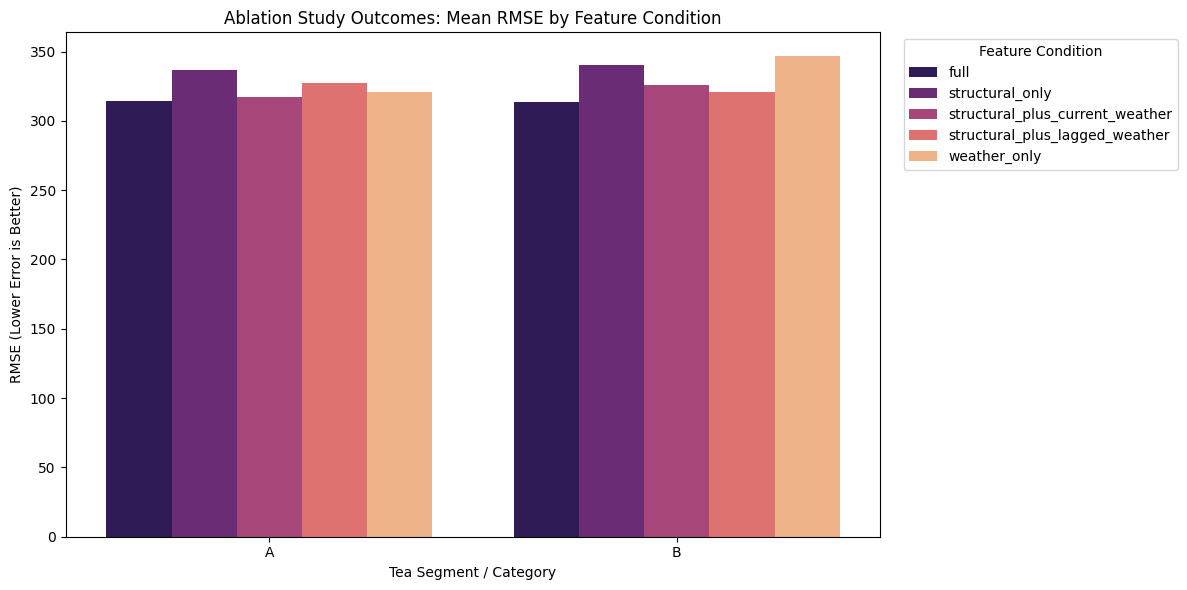

In [ ]:
# --- OPTIONAL: COMPACT VISUALIZATION ---
plt.figure(figsize=(12, 6))

# A grouped barplot accurately conveying how the conditions performed structurally 
sns.barplot(data=summary_df, x='segment', y='rmse_mean', hue='condition', palette='magma')

plt.title("Ablation Study Outcomes: Mean RMSE by Feature Condition")
plt.ylabel("RMSE (Lower Error is Better)")
plt.xlabel("Tea Segment / Category")

# Move the legend outside to maintain chart clarity
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Feature Condition")
plt.tight_layout()

plt.savefig("../reports/figures/ablation_rmse_bar_chart.png", dpi=300)
plt.show()